This project investigates whether stress-related gene expression and neuronal electrophysiological properties relate to functional activation in the prefrontal cortex (PFC) during reward and punishment processing.

We integrate three large neuroscience datasets:

• Human Connectome Project (HCP) - task fMRI activation  
• Allen Human Brain Atlas - gene expression  
• Allen Cell Types Database - electrophysiological properties  

Specifically, we test whether PFC regions with stronger task activation during punishment show:

1. Higher expression of stress-related genes (NR3C1 and NR3C2)
2. Greater neuronal excitability (f–I curve slope)

This multimodal approach allows us to connect molecular, cellular, and systems-level brain data.

## Environment Setup

We begin by importing all required Python packages for neuroimaging analysis, atlas-based parcellation, gene expression mapping, electrophysiology processing, statistics, and visualization.

In [1]:
import sys
print(sys.executable)

import nibabel as nib
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import abagen
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from scipy import stats
import zipfile
import os

print("All working!")

c:\Users\user\myenv\Scripts\python.exe
All working!


# Data Wrangling

In this section, we load each dataset into Python, isolate the observations relevant to our research question, and preprocess the data so that all three modalities can be compared across prefrontal cortex regions.

The three data modalities are:

1. Task fMRI activation from the HCP Gambling Task
2. Regional gene expression from the Allen Human Brain Atlas
3. Neuronal electrophysiology from the Allen Cell Types Database

Because these datasets use different file formats and anatomical conventions, preprocessing and region matching are required before integration.

### Analysis Pipeline Overview

This project integrates three neuroscience datasets to examine relationships between stress-related gene expression, neuronal electrophysiology, and task fMRI activation in the prefrontal cortex.

The analysis pipeline follows these steps:

1. Load task fMRI activation maps from the Human Connectome Project gambling task.
2. Parcellate voxelwise activation into cortical regions using the Schaefer 100-region atlas.
3. Restrict the analysis to parcels located in the prefrontal cortex.
4. Map gene expression data from the Allen Human Brain Atlas to the same atlas parcels.
5. Extract neuronal electrophysiological properties from the Allen Cell Types Database.
6. Aggregate neuron-level electrophysiology into region-level estimates of excitability.
7. Merge fMRI activation, gene expression, and electrophysiology into a unified parcel-level dataset.
8. Perform statistical analyses to test relationships between these modalities.

## Load Allen Cell Types Database tools

We use the AllenSDK to access human electrophysiology data from the Allen Cell Types Database. This dataset contains patch-clamp measurements from individual neurons, including firing-rate and membrane-response properties that can be used as measures of neuronal excitability.

In [2]:
pip install allensdk

In [3]:
# Import the "Cell Types Cache" from the AllenSDK core package
from allensdk.core.cell_types_cache import CellTypesCache

# Import CellTypesApi in order to query the database.
from allensdk.api.queries.cell_types_api import CellTypesApi

# Initialize the cache as 'ctc' (cell types cache)
ctc = CellTypesCache(manifest_file=r'C:\Users\user\Downloads\abagen_data\cell_types_manifest.json')

## Load Human Connectome Project task fMRI data

We next load task-based fMRI statistical maps from the Human Connectome Project Gambling Task.

We focus on three contrasts:

- Reward > punishment
- Reward
- Punishment

These NIfTI maps quantify voxelwise BOLD activation and will later be summarized into atlas-defined cortical parcels.

In [4]:
import zipfile
import os

zip_path = r'C:\Users\user\Downloads\The+WU-Minn+Human+Connectome+Project_+An+overview.zip'
extract_path = r'C:\Users\user\Downloads\hcp_gambling'

# make the destination folder
os.makedirs(extract_path, exist_ok=True)

# extract the zip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))

Extracted files:
['The WU-Minn Human Connectome Project_ An overview']


In [5]:
base = r'C:\Users\user\Downloads\hcp_gambling\The WU-Minn Human Connectome Project_ An overview'
for f in os.listdir(base):
    print(repr(f))

'tfMRI_EMOTION_FACES-SHAPES_zstat1.nii.gz'
'tfMRI_EMOTION_FACES_zstat1.nii.gz'
'tfMRI_EMOTION_SHAPES_zstat1.nii.gz'
'tfMRI_GAMBLING_PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD-PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD_zstat1.nii.gz'
'tfMRI_LANGUAGE_MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY-MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY_zstat1.nii.gz'
'tfMRI_MOTOR_AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE_zstat1.nii.gz'
'tfMRI_MOTOR_LF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LF_zstat1.nii.gz'
'tfMRI_MOTOR_LH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LH_zstat1.nii.gz'
'tfMRI_MOTOR_RF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RF_zstat1.nii.gz'
'tfMRI_MOTOR_RH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RH_zstat1.nii.gz'
'tfMRI_MOTOR_T-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_T_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH-REL_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH_zstat1.nii.gz'
'tfMRI_RELATIONAL_REL-MATCH.nii_tstat1.nii.gz'
'tfMRI_RELATIONAL_REL_zstat1.nii.gz'
'tfMRI_SOCIAL_RANDOM_zstat1.nii.gz'
'tfMRI_SOCIAL_TOM-

In [6]:
# load fmri statistical maps from the hcp gambling task

# reward > punish contrast map
reward_punish = nib.load(os.path.join(base, 'tfMRI_GAMBLING_REWARD-PUNISH_zstat1.nii.gz'))

# reward condition activation map
reward = nib.load(os.path.join(base, 'tfMRI_GAMBLING_REWARD_zstat1.nii.gz'))

# punish condition activation map
punish = nib.load(os.path.join(base, 'tfMRI_GAMBLING_PUNISH_zstat1.nii.gz'))

print("reward_punish:", reward_punish.shape)
print("reward:", reward.shape)
print("punish:", punish.shape)

reward_punish: (91, 109, 91)
reward: (91, 109, 91)
punish: (91, 109, 91)


## Inspect the HCP activation map

Before parcellating the data, we inspect the Reward > Punishment map to confirm that the dataset loads correctly and shows plausible activation structure.

Peak activation at voxel: (39, 17, 45)


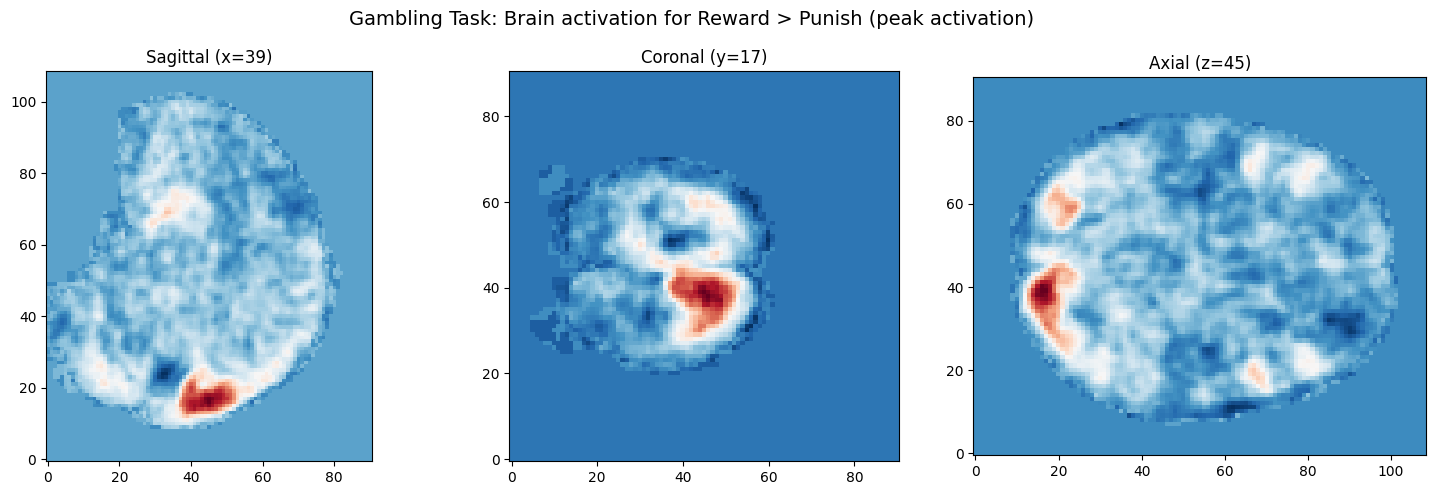

In [7]:
# extract the raw voxel data from the NIfTI image as a numpy array
data = reward_punish.get_fdata()

# find the voxel location with the maximum activation value
peak = np.unravel_index(np.argmax(data), data.shape)
print("Peak activation at voxel:", peak)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# show the sagittal slice (x-plane) passing through the peak voxel
axes[0].imshow(data[peak[0], :, :], cmap='RdBu_r', origin='lower')
axes[0].set_title(f'Sagittal (x={peak[0]})')

# show the coronal slice (y-plane) passing through the peak voxel
axes[1].imshow(data[:, peak[1], :], cmap='RdBu_r', origin='lower')
axes[1].set_title(f'Coronal (y={peak[1]})')

# show the axial slice (z-plane) passing through the peak voxel
axes[2].imshow(data[:, :, peak[2]], cmap='RdBu_r', origin='lower')
axes[2].set_title(f'Axial (z={peak[2]})')

plt.suptitle('Gambling Task: Brain activation for Reward > Punish (peak activation)', fontsize=14)
plt.tight_layout()
plt.show()

# red = stronger activation during reward > punishment (positive Z-stat)
# blue = stronger activation during punishment > reward (negative Z-stat)
# white = little difference between conditions

This figure is an exploratory check of the raw HCP Reward > Punishment Z-statistic map before atlas-based parcellation. Its main purpose is to confirm that the task data show a biologically plausible activation pattern rather than noise or loading errors. 

The strongest positive activation cluster (red) appears in the bilateral striatum/caudate nucleus, consistent with well-established reward processing circuitry recruited during gambling tasks. Diffuse blue regions reflect areas more active during punishment than reward, including medial PFC which is consistent with known default mode network patterns. This figure validates the fMRI dataset and confirms that the task contrast captures meaningful reward-related signal before the data are reduced to 19 PFC parcel averages for cross-modal analysis.

In [8]:
# define the voxel coordinates of the peak activation in the fmri volume
voxel_coords = np.array([39, 17, 45, 1]) # confirms exact brain region

# convert voxel coordinates to mni (world) coords
mni_coords = reward_punish.affine @ voxel_coords
print(f"Peak activation in MNI space: x={mni_coords[0]:.1f}, y={mni_coords[1]:.1f}, z={mni_coords[2]:.1f}")

Peak activation in MNI space: x=12.0, y=-92.0, z=18.0


## Parcellate fMRI activation into cortical regions

To compare fMRI activation with gene expression and electrophysiology, we summarize voxelwise activation into cortical parcels using the Schaefer 100-region atlas.

For each parcel, we extract average activation values for the Reward > Punishment, Reward, and Punishment maps.

In [9]:
# download the schaefer 2018 brain atlas
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, resolution_mm=2)

# load the nifti image containing the atlas parcellation map
atlas_img    = atlas.maps

# load the list of parcel names associated with the atlas labels
atlas_labels = atlas.labels

print("Parcels:", len(atlas_labels))

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\user\nilearn_data\schaefer_2018
Parcels: 101


In [10]:
# create a masker that will extract average fmri signal within each atlas parcel
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=False) #parcellate the fMRI data
masker.fit()

# extract the mean activation value within each atlas parcel
rp_activation = masker.transform(reward_punish).flatten()

# extract parcel-level activation for the reward contrast
r_activation  = masker.transform(reward).flatten()

# extract parcel-level activation for the punish contrast
p_activation  = masker.transform(punish).flatten()

print("Number of parcels:", len(rp_activation))

Number of parcels: 100


In [11]:
# convert atlas labels to strings

labels = [l.decode() if isinstance(l, bytes) else l for l in atlas_labels] # create clean dataframe
labels = labels[1:]  # remove background label so it matches the 100 lenght

# create dataframe that stores parcel-level activation values
activation_df = pd.DataFrame({
    'parcel_label':  labels,
    'reward_punish': rp_activation,
    'reward':        r_activation,
    'punish':        p_activation
})

print(activation_df.shape)
print(activation_df.head(10))

(100, 4)
            parcel_label  reward_punish     reward     punish
0     7Networks_LH_Vis_1       2.193728  -2.365583  -4.383722
1     7Networks_LH_Vis_2       5.432561  21.081312  19.977684
2     7Networks_LH_Vis_3       2.293952  12.808895  11.621621
3     7Networks_LH_Vis_4       3.306230   9.834748   8.662894
4     7Networks_LH_Vis_5       5.797865  21.320940  20.318979
5     7Networks_LH_Vis_6       3.396118  14.053095  12.721108
6     7Networks_LH_Vis_7       4.504007   9.674089   7.896776
7     7Networks_LH_Vis_8       5.718954  15.587968  14.110069
8     7Networks_LH_Vis_9       4.312005   6.541833   4.565026
9  7Networks_LH_SomMot_1      -1.403067  -7.825548  -6.715819


Here we create a dataframe that stores the fMRI activation values for each Schaefer atlas parcel. Each row represents one brain region with its activation during the reward, punishment, and reward–punishment conditions from the HCP gambling task.

## Restrict the analysis to prefrontal cortex parcels

Our hypothesis focuses on the prefrontal cortex (PFC), so we isolate PFC-related parcels from the full Schaefer atlas.

We use parcel labels containing terms such as Frontal, Cingulate, Orbital, ACC, and PFC.

In [12]:
pfc_keywords = ['Frontal', 'Cingulate', 'Orbital', 'ACC', 'PFC'] # common keywords in PFC parcel names to filter (this is a heuristic, not perfect)

# create a boolean mask that checks whether each parcel label contains any pfc keyword
pfc_mask = activation_df['parcel_label'].apply(
    lambda x: any(kw in str(x) for kw in pfc_keywords)
)

# filter the activation dataframe to keep only parcels that match the pfc keywordsd
pfc_activation_df = activation_df[pfc_mask].copy()

print(f"PFC parcels found: {len(pfc_activation_df)}")
print(pfc_activation_df)

print("Saved!")

PFC parcels found: 19
                       parcel_label  reward_punish     reward     punish
26  7Networks_LH_SalVentAttn_PFCl_1       0.933066   1.704450   1.165623
34         7Networks_LH_Cont_PFCl_1       4.248331   6.875048   4.174028
41       7Networks_LH_Default_PFC_1       0.590334   4.340418   4.118737
42       7Networks_LH_Default_PFC_2       2.493776  -0.092886  -1.991885
43       7Networks_LH_Default_PFC_3       3.206620 -10.709704 -12.445906
44       7Networks_LH_Default_PFC_4       2.256133   0.321182  -1.537834
45       7Networks_LH_Default_PFC_5       1.400125  -8.345525  -8.824366
46       7Networks_LH_Default_PFC_6       2.717208   1.892875   0.298158
47       7Networks_LH_Default_PFC_7       3.705171  -7.149555  -9.271638
82         7Networks_RH_Cont_PFCl_1       1.311936   8.117070   6.743384
83         7Networks_RH_Cont_PFCl_2       3.242302  10.452598   8.488015
84         7Networks_RH_Cont_PFCl_3      -0.662504   9.729884   9.918179
85         7Networks_RH_Cont_

From this, there are 19 PFC parcels identified left (LH) and right (RH) hemispheres with "reward_punish column" as the primary variable for our research question.
Some notable findings:
- LH_Cont_PFCl_1 has strong reward>punish activation (4.25) — likely dlPFC
- LH_Default_PFC_3 shows strong negative punish activation (-12.4) — likely vmPFC
- Right hemisphere Cont_PFCl parcels show very strong reward activation

## Load gene expression data from the Allen Human Brain Atlas

We use the `abagen` package to map postmortem microarray gene expression data from the Allen Human Brain Atlas onto the same Schaefer atlas used for the fMRI data.

This allows us to obtain parcel-level gene expression values that can be directly compared with fMRI activation.

We focus on two stress-related receptor genes:

- NR3C1: glucocorticoid receptor (GR)
- NR3C2: mineralocorticoid receptor (MR)

In [13]:
print(abagen.__version__)

# download Allen Human Brain Atlas data (~4GB, one time only)
files = abagen.fetch_microarray(
    donors='all',
    data_dir=r'C:\Users\user\Downloads\abagen_data',
    verbose=1
)
print("Download complete!")
print(files)

0.1.3
Download complete!
{'9861': {'microarray': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\MicroarrayExpression.csv', 'ontology': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\Ontology.csv', 'pacall': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\PACall.csv', 'probes': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\Probes.csv', 'annotation': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\SampleAnnot.csv'}, '10021': {'microarray': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\MicroarrayExpression.csv', 'ontology': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\Ontology.csv', 'pacall': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\PACall.csv', 'probes': 'C:\\Use

In [14]:
# create a list that will store metadata for each atlas parcel
info_rows = []

# loop through each atlas label and build a row of metadata for abagen
for i, label in enumerate(labels):
    info_rows.append({
        'id':         i + 1, # atlas parcel id
        'label':      label, # parcel name from the schaefer atlas
        'hemisphere': 'L' if 'LH' in label else 'R', # determine hemisphere based on the label name
        'structure':  'cortex'
    })

# convert the metadata list into a dataframe
info_df = pd.DataFrame(info_rows)
info_path = r'C:\Users\user\Downloads\abagen_data\schaefer100_info.csv'
info_df.to_csv(info_path, index=False)
print(info_df.head())

# extract gene expression data from the allen human brain atlas
expression = abagen.get_expression_data(
    atlas=atlas_img, # atlas image defining brain parcels
    atlas_info=info_path, # metadata describing parcel ids and hemispheres
    data_dir=r'C:\Users\user\Downloads\abagen_data', # loc of downloaded microarray data
)

print("Expression matrix shape:", expression.shape)
print(expression[['NR3C1', 'NR3C2']])

   id               label hemisphere structure
0   1  7Networks_LH_Vis_1          L    cortex
1   2  7Networks_LH_Vis_2          L    cortex
2   3  7Networks_LH_Vis_3          L    cortex
3   4  7Networks_LH_Vis_4          L    cortex
4   5  7Networks_LH_Vis_5          L    cortex


c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `ob

Expression matrix shape: (100, 15633)
gene_symbol     NR3C1     NR3C2
label                          
1            0.230507  0.343005
2            0.663663  0.729475
3            0.779345  0.757218
4            0.795031  0.813979
5            0.831664  0.823680
...               ...       ...
96           0.442110  0.505301
97           0.391887  0.488488
98           0.597723  0.531846
99           0.720400  0.563838
100          0.634292  0.503785

[100 rows x 2 columns]


Here we build the metadata needed for the Schaefer atlas so that `abagen` can map gene expression data to each brain parcel. Then we extract gene expression values from the Allen Human Brain Atlas and look specifically at the stress-related genes NR3C1 and NR3C2 across the parcels.

## Merge gene expression with parcel-level fMRI activation

We extract NR3C1 and NR3C2 expression values for the same PFC parcels retained from the fMRI analysis and combine them into a single dataframe.

At this stage, each row corresponds to a PFC parcel and includes:

- Reward > punishment activation
- Reward activation
- Punishment activation
- NR3C1 expression
- NR3C2 expression

In [15]:
pfc_gene_expr = expression[['NR3C1', 'NR3C2']].loc[ # filters the expression data to only NR3C1 and NR3C2 for PFC parcels based on their labels
    pfc_activation_df.index + 1  # +1 because parcel IDs start at 1
]

print("PFC gene expression:")
print(pfc_gene_expr)

PFC gene expression:
gene_symbol     NR3C1     NR3C2
27           0.554992  0.501374
35           0.723660  0.619719
42           0.380591  0.297385
43           0.654948  0.508460
44           0.362587  0.405948
45           0.573528  0.513639
46           0.510094  0.476720
47           0.591716  0.522715
48           0.518701  0.466388
83           0.509482  0.586418
84           0.648094  0.686884
85           0.617731  0.543383
86           0.767637  0.397417
88           0.454486  0.358151
94           0.668436  0.530913
95           0.593548  0.472750
96           0.442110  0.505301
97           0.391887  0.488488
98           0.597723  0.531846


This output shows the gene expression values for the stress-related genes NR3C1 and NR3C2 in the PFC parcels we selected. Each row corresponds to a brain parcel, and the numbers represent the normalized expression level of each gene in that region.

In [16]:
pfc_activation_reset = pfc_activation_df.reset_index(drop=True) # mergres the activation and gene expression dataframes for the PFC parcels, resetting the index so they align properly
pfc_gene_reset = pfc_gene_expr.reset_index(drop=True)

# combine the activation data and gene expression data side-by-side
combined_df = pd.concat([pfc_activation_reset, pfc_gene_reset], axis=1)
print("Combined dataframe:")
print(combined_df)

Combined dataframe:
                       parcel_label  reward_punish     reward     punish  \
0   7Networks_LH_SalVentAttn_PFCl_1       0.933066   1.704450   1.165623   
1          7Networks_LH_Cont_PFCl_1       4.248331   6.875048   4.174028   
2        7Networks_LH_Default_PFC_1       0.590334   4.340418   4.118737   
3        7Networks_LH_Default_PFC_2       2.493776  -0.092886  -1.991885   
4        7Networks_LH_Default_PFC_3       3.206620 -10.709704 -12.445906   
5        7Networks_LH_Default_PFC_4       2.256133   0.321182  -1.537834   
6        7Networks_LH_Default_PFC_5       1.400125  -8.345525  -8.824366   
7        7Networks_LH_Default_PFC_6       2.717208   1.892875   0.298158   
8        7Networks_LH_Default_PFC_7       3.705171  -7.149555  -9.271638   
9          7Networks_RH_Cont_PFCl_1       1.311936   8.117070   6.743384   
10         7Networks_RH_Cont_PFCl_2       3.242302  10.452598   8.488015   
11         7Networks_RH_Cont_PFCl_3      -0.662504   9.729884   9.91

^ Created a new dataframe combining gene expression and fMRI datasets. Now we look at electrohpysiology.

## Extract electrophysiology features from human PFC neurons

We next incorporate neuronal electrophysiology from the Allen Cell Types Database.

This dataset contains measurements from individual neurons rather than atlas parcels, so we:

1. restrict to human cells,
2. merge cell metadata with electrophysiology features,
3. isolate broad PFC anatomical regions,
4. compute region-level summary statistics.

We use the f-I curve slope as our main measure of neuronal excitability.

In [17]:
# retrieve cell metadata from the allen cell types database
cells = ctc.get_cells(species=['Homo Sapiens'], require_reconstruction=False) #makes sure only using human cells
cells_df = pd.DataFrame(cells)

print("Total human cells:", len(cells_df))
print("Columns:", cells_df.columns.tolist())

# retrieve electrophysiological feature measurements for cells
# these include properties such as firing rate slope and membrane time constant
ephys = ctc.get_ephys_features()
ephys_df = pd.DataFrame(ephys)

print("Ephys features shape:", ephys_df.shape)
print("Columns:", ephys_df.columns.tolist())

# merge the cell metadata with the electrophysiology features
merged = cells_df.merge(ephys_df, left_on='id', right_on='specimen_id', how='inner')
print("Merged shape:", merged.shape)
print(merged[['structure_area_abbrev', 'f_i_curve_slope', 'threshold_i_long_square', 'tau']].head(10))

Total human cells: 413
Columns: ['reporter_status', 'cell_soma_location', 'species', 'id', 'name', 'structure_layer_name', 'structure_area_id', 'structure_area_abbrev', 'transgenic_line', 'dendrite_type', 'apical', 'reconstruction_type', 'disease_state', 'donor_id', 'structure_hemisphere', 'normalized_depth']
Ephys features shape: (2333, 56)
Columns: ['adaptation', 'avg_isi', 'electrode_0_pa', 'f_i_curve_slope', 'fast_trough_t_long_square', 'fast_trough_t_ramp', 'fast_trough_t_short_square', 'fast_trough_v_long_square', 'fast_trough_v_ramp', 'fast_trough_v_short_square', 'has_burst', 'has_delay', 'has_pause', 'id', 'input_resistance_mohm', 'latency', 'peak_t_long_square', 'peak_t_ramp', 'peak_t_short_square', 'peak_v_long_square', 'peak_v_ramp', 'peak_v_short_square', 'rheobase_sweep_id', 'rheobase_sweep_number', 'ri', 'sag', 'seal_gohm', 'slow_trough_t_long_square', 'slow_trough_t_ramp', 'slow_trough_t_short_square', 'slow_trough_v_long_square', 'slow_trough_v_ramp', 'slow_trough_v_sh

^ We successfully loaded electrophysiology data for 413 human neurons from the Allen Cell Types Database. The merged dataset includes properties like the f–I curve slope (neuronal excitability), rheobase current (threshold_i_long_square), and membrane time constant (`au) for neurons across different brain regions.

## Aggregate electrophysiology within broad PFC regions

Because electrophysiology measurements are recorded at the level of individual neurons, we average these properties within broader PFC anatomical regions.

This produces region-level excitability estimates that can be compared to parcel-level fMRI activation and gene expression, although the electrophysiology mapping is spatially coarser.

In [18]:
pfc_regions = ['FroL', 'MFG', 'IFG', 'SFG'] # filter PFC regions
pfc_ephys = merged[merged['structure_area_abbrev'].isin(pfc_regions)].copy() # select only neurons recorded from these pfc regions

print(f"PFC neurons found: {len(pfc_ephys)}")
print(pfc_ephys[['structure_area_abbrev', 'f_i_curve_slope', 
                  'threshold_i_long_square', 'tau']].head(10))

# group neurons by anatomical region and compute average electrophysiological properties
# this summarizes neuron-level data into region-level metrics
firing_rates = pfc_ephys.groupby('structure_area_abbrev').agg(
    mean_fi_slope=('f_i_curve_slope', 'mean'), # average firing rate slope (excitability)
    mean_rheobase=('threshold_i_long_square', 'mean'), # average current needed to trigger a spike
    mean_tau=('tau', 'mean'), # average membrane time constant
    n_cells=('f_i_curve_slope', 'count') # number of neurons recorded in each region
).reset_index()

print(firing_rates)

PFC neurons found: 56
   structure_area_abbrev  f_i_curve_slope  threshold_i_long_square        tau
0                   FroL         0.167187                     90.0  21.181026
6                    MFG         0.179187                     70.0  18.539072
11                  FroL         0.462723                    290.0   5.725947
17                  FroL         0.059375                    190.0  20.750404
25                  FroL         0.058036                    330.0  15.361737
28                   IFG         0.038750                    190.0   5.698774
34                   MFG         0.269186                     40.0  24.430249
40                  FroL         0.025000                    450.0  15.356045
53                   IFG         0.072876                    250.0  15.025867
61                  FroL         0.000460                    650.0  12.741367
  structure_area_abbrev  mean_fi_slope  mean_rheobase   mean_tau  n_cells
0                  FroL       0.099739     267

^ Created new dataframe with all 3 datasets merged: electrophysiology, gene expression and fMRI imaging

## Create the final integrated multimodal dataset

Finally, we map the broad electrophysiology regions onto the PFC parcels and merge all three modalities into one dataframe.

The final integrated dataset contains, for each PFC parcel:

- task fMRI activation
- stress receptor gene expression
- mapped electrophysiology summary values

This dataframe is used for all subsequent visualization and statistical analysis.

In [19]:
from scipy.stats import spearmanr

# define a mapping between schaefer atlas parcel name patterns and electrophysiology regions
region_map = {
    'Cont_PFCl':        'MFG',
    'SalVentAttn_PFCl': 'IFG',
    'Default_PFC':      'FroL',
    'Default_PFCdPFCm': 'SFG',
    'Default_PFCv':     'FroL',
    'Cont_PFCmp':       'MFG'
}

# map each parcel to its ephys region
combined_df['ephys_region'] = combined_df['parcel_label'].apply( 
    lambda x: next((v for k, v in region_map.items() if k in x), None)
)

# merge firing rates in
combined_df = combined_df.merge( # Mmrge firing rates
    firing_rates,
    left_on='ephys_region',
    right_on='structure_area_abbrev',
    how='left'
)

print(combined_df[['parcel_label', 'reward_punish', 'NR3C1', 'NR3C2', 'mean_fi_slope']].to_string())

                       parcel_label  reward_punish     NR3C1     NR3C2  mean_fi_slope
0   7Networks_LH_SalVentAttn_PFCl_1       0.933066  0.554992  0.501374       0.143389
1          7Networks_LH_Cont_PFCl_1       4.248331  0.723660  0.619719       0.138967
2        7Networks_LH_Default_PFC_1       0.590334  0.380591  0.297385       0.099739
3        7Networks_LH_Default_PFC_2       2.493776  0.654948  0.508460       0.099739
4        7Networks_LH_Default_PFC_3       3.206620  0.362587  0.405948       0.099739
5        7Networks_LH_Default_PFC_4       2.256133  0.573528  0.513639       0.099739
6        7Networks_LH_Default_PFC_5       1.400125  0.510094  0.476720       0.099739
7        7Networks_LH_Default_PFC_6       2.717208  0.591716  0.522715       0.099739
8        7Networks_LH_Default_PFC_7       3.705171  0.518701  0.466388       0.099739
9          7Networks_RH_Cont_PFCl_1       1.311936  0.509482  0.586418       0.138967
10         7Networks_RH_Cont_PFCl_2       3.242302  0.

## Observations and missing data

After filtering to the prefrontal cortex, the final integrated dataset contains 19 PFC parcels.

Important notes:

- The Schaefer atlas contains 100 cortical parcels in total.
- After PFC filtering, 19 parcels were retained for analysis.
- Gene expression values were available for all retained parcels.
- Electrophysiology values were mapped from 4 broader PFC anatomical regions to the 19 parcels.

This means the electrophysiology data are spatially coarser than the fMRI and gene expression data, and multiple parcels share the same electrophysiology value. This reduces spatial precision and statistical power, but does not create missing values in the final integrated dataset.

## Spearman and Pearson Correlations

To evaluate relationships between modalities, both Spearman rank correlation and Pearson correlation analyses were performed.

Spearman correlation was used to evaluate monotonic relationships that may not be strictly linear and is more robust to outliers. Pearson correlation was used to assess linear relationships between variables.

These statistical tests were applied to examine relationships between:

- fMRI activation during reward and punishment processing
- expression of stress-related genes (NR3C1 and NR3C2)
- neuronal excitability measured by the f–I curve slope

Statistical significance was evaluated using p-values with a threshold of p < 0.05.

Note: The correlations were computed across 19 prefrontal cortex parcels that remained after filtering the Schaefer atlas to PFC regions.

In [20]:
from scipy.stats import spearmanr, pearsonr

# define pairs of variables to test relationships between
pairs = [
    ('reward_punish', 'NR3C1',         'fMRI Activation vs NR3C1'),
    ('reward_punish', 'NR3C2',         'fMRI Activation vs NR3C2'),
    ('reward_punish', 'mean_fi_slope', 'fMRI Activation vs Excitability'),
    ('NR3C1',         'mean_fi_slope', 'NR3C1 vs Excitability'),
    ('NR3C2',         'mean_fi_slope', 'NR3C2 vs Excitability'),
    ('punish',        'NR3C1',         'Punishment Activation vs NR3C1'),
    ('punish',        'NR3C2',         'Punishment Activation vs NR3C2'),
]

results = []

# loop through each variable pair and compute correlations
for x, y, label in pairs:
    data = combined_df[[x, y]].dropna()
    rho, p_s = spearmanr(data[x], data[y]) # compute spearman rank correlation (captures monotonic relationships)
    r, p_p   = pearsonr(data[x], data[y]) # compute pearson correlation (measures linear relationships)
    sig = '***' if p_s < 0.001 else ('**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')) # assign significance stars based on spearman p-value
    results.append({'comparison': label, 'spearman_r': round(rho,3), 
                    'spearman_p': round(p_s,4), 'pearson_r': round(r,3),
                    'pearson_p': round(p_p,4), 'significant': p_s < 0.05})
    print(f"{label}")
    print(f"  Spearman r={rho:.3f}, p={p_s:.4f} {sig}")
    print(f"  Pearson  r={r:.3f},   p={p_p:.4f}\n")

fMRI Activation vs NR3C1
  Spearman r=0.270, p=0.2633 ns
  Pearson  r=0.259,   p=0.2849

fMRI Activation vs NR3C2
  Spearman r=0.240, p=0.3216 ns
  Pearson  r=0.359,   p=0.1310

fMRI Activation vs Excitability
  Spearman r=-0.223, p=0.3599 ns
  Pearson  r=-0.185,   p=0.4483

NR3C1 vs Excitability
  Spearman r=0.291, p=0.2271 ns
  Pearson  r=0.370,   p=0.1190

NR3C2 vs Excitability
  Spearman r=0.254, p=0.2949 ns
  Pearson  r=0.278,   p=0.2491

Punishment Activation vs NR3C1
  Spearman r=0.463, p=0.0458 *
  Pearson  r=0.507,   p=0.0267

Punishment Activation vs NR3C2
  Spearman r=0.211, p=0.3870 ns
  Pearson  r=0.125,   p=0.6106



Only significant finding:
Punishment Activation vs NR3C1: r=0.463, p=0.046

PFC subregions were more activated during punishment/loss also expressing more NR3C1 (glucocorticoid receptor). This directly supports our hypothesis about stress sensitivity and makes biological sense given NR3C1 is the primary cortisol receptor, and punishment/loss is inherently stressful.

Why reward_punish contrast showed nothing (ns):

- The difference score washes out the signal.
- Reward and punishment activate overlapping PFC regions, so subtracting them removes the variance that correlates with gene expression.

Why excitability correlations were ns:

- The Allen Cell Types data only had 4 PFC region categories mapped to 19 parcels — too coarse a mapping.
- Many parcels shared the same firing rate value, reducing statistical power.

# Data Visualization

This section contains both exploratory and hypothesis-driven visualizations.

These plots are used to:

- inspect raw fMRI activation patterns
- compare stress receptor expression across PFC parcels
- examine distributions of neuronal excitability
- visualize relationships among modalities

### Figure 1. Multimodal Correlation Structure Across PFC Subregions

To explore relationships among the different modalities in our dataset, we compute a Spearman correlation matrix across key variables:

• fMRI activation measures (reward, punish, reward–punish contrast)  
• stress hormone receptor gene expression (NR3C1, NR3C2)  
• neuronal excitability (mean f-I curve slope)

Spearman correlation is used because it captures monotonic relationships and is less sensitive to outliers than Pearson correlation. The heatmap provides a global overview of how functional activation, gene expression, and electrophysiology relate to each other across prefrontal cortex parcels.

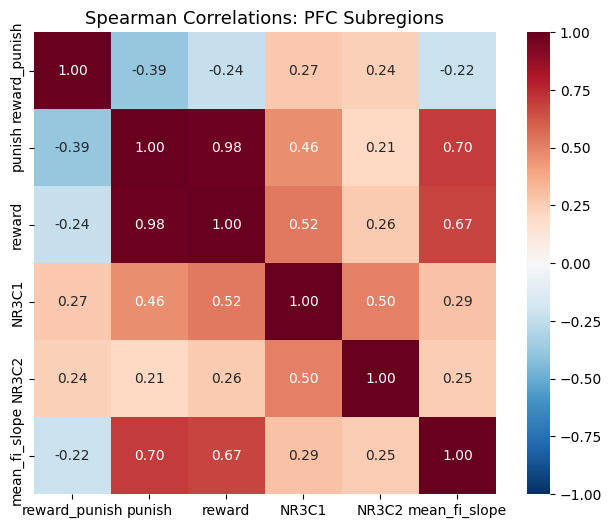

In [21]:
# select the columns to include in the correlation analysis
# these represent functional activation, gene expression, and electrophysiology
cols = ['reward_punish', 'punish', 'reward', 'NR3C1', 'NR3C2', 'mean_fi_slope']

# compute the spearman correlation matrix between the selected variables
corr = combined_df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))

# plot the correlation matrix as a heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman Correlations: PFC Subregions', fontsize=13)
plt.savefig(r'C:\Users\user\Downloads\correlation_heatmap.png', dpi=150)
plt.show()

This heatmap shows how fMRI activation, gene expression, and electrophysiological properties relate to each other across PFC parcels.

The strongest relationship is between the reward and punishment activation maps (r ≈ 0.98), indicating that many of the same PFC regions respond during both outcomes in the gambling task. There is also a strong positive correlation between punishment activation and neuronal excitability (r ≈ 0.70), suggesting that regions with more excitable neurons tend to show stronger responses during negative outcomes.

NR3C1 expression shows moderate positive relationships with both reward and punishment activation (r ≈ 0.46–0.52), while NR3C2 shows weaker associations. The reward–punish contrast shows weaker correlations overall, likely because it subtracts two highly similar activation patterns.

Overall, these results suggest that neuronal excitability and glucocorticoid receptor expression may both relate to functional activation patterns across the PFC.

### Figure 2. Punishment-related PFC activation vs stress receptor gene expression

This figure directly tests the central hypothesis of the project: whether prefrontal cortex regions that respond more strongly during punishment outcomes also show higher expression of stress hormone receptor genes.

Each point represents a PFC parcel. The x-axis shows the parcel’s punishment-related fMRI activation (Z-statistic), while the y-axis shows normalized gene expression values from the Allen Human Brain Atlas. Two panels are shown to compare the two stress receptor systems:

• NR3C1 — glucocorticoid receptor (GR), the primary receptor mediating cortisol stress responses  
• NR3C2 — mineralocorticoid receptor (MR), associated more with baseline stress regulation

Comparing these two receptors allows us to determine whether stress-sensitive functional activation is more strongly associated with GR- or MR-related signaling.

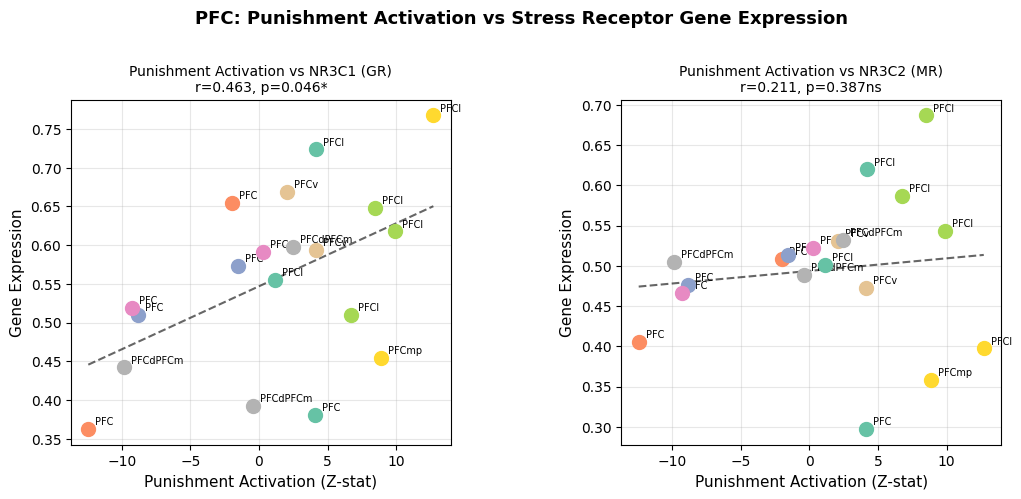

In [22]:
# create a figure with two side-by-side subplots for the two scatter comparisons
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.45, top=0.80)

# add more spacing between the plots
plt.subplots_adjust(wspace=0.45)

# define the variable pairs to plot
scatter_pairs = [
    ('punish', 'NR3C1', 'Punishment Activation vs NR3C1 (GR)', 'r=0.463, p=0.046*'),
    ('punish', 'NR3C2', 'Punishment Activation vs NR3C2 (MR)', ''),
]

colors = plt.cm.Set2(np.linspace(0, 1, len(combined_df)))

# loop through each subplot and corresponding variable pair
for ax, (x, y, title, stats) in zip(axes, scatter_pairs):
    data = combined_df[[x, y, 'parcel_label']].dropna()
    
    # calculate correlation stats if not provided
    if not stats:
        rho, pval = spearmanr(data[x], data[y])
        sig = '*' if pval < 0.05 else 'ns'
        stats = f'r={rho:.3f}, p={pval:.3f}{sig}'
    
    # plot each parcel as an individual scatter point
    for i, (_, row) in enumerate(data.iterrows()):
        ax.scatter(row[x], row[y], s=100, color=colors[i], zorder=5)
        ax.annotate(row['parcel_label'].split('_')[-2],
                   (row[x], row[y]),
                   textcoords="offset points", xytext=(5,3), fontsize=7)
    
    # fit regression line
    z = np.polyfit(data[x], data[y], 1)
    p = np.poly1d(z)
    
    x_line = np.linspace(data[x].min(), data[x].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', alpha=0.6, linewidth=1.5)
    
    ax.set_xlabel('Punishment Activation (Z-stat)', fontsize=11)
    ax.set_ylabel('Gene Expression', fontsize=11)
    ax.set_title(f'{title}\n{stats}', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('PFC: Punishment Activation vs Stress Receptor Gene Expression', 
             fontsize=13, fontweight='bold')

plt.show()

These plots reveal an important difference between the two stress receptor systems.

The left panel shows a moderate positive correlation between punishment activation and NR3C1 expression (r = 0.463, p = 0.046). This indicates that PFC parcels with stronger neural responses to punishment outcomes tend to express higher levels of glucocorticoid receptors. Because NR3C1 mediates cortisol signaling during stress, this relationship suggests that regions recruited during negative or risky outcomes may also be regions that are more sensitive to stress hormone modulation.

In contrast, the right panel shows no significant relationship between punishment activation and NR3C2 expression (r = 0.211, p = 0.387). The points are more widely scattered and the trend line is nearly flat, indicating that mineralocorticoid receptor expression does not strongly track variation in task-evoked activation across PFC parcels.

This dissociation between NR3C1 and NR3C2 is biologically meaningful. While both receptors bind cortisol, NR3C1 is typically associated with dynamic stress responses, whereas NR3C2 plays a larger role in baseline regulation of stress hormone signaling. The results therefore suggest that PFC regions recruited during punishment processing may be specifically linked to glucocorticoid-mediated stress pathways rather than to mineralocorticoid signaling.

Overall, this figure provides evidence supporting the project hypothesis that stress-related molecular properties of PFC regions may contribute to differences in functional activation during risk-related decision processes.

#### Composite ranking of PFC parcels by multimodal stress sensitivity

To identify which prefrontal cortex parcels appear most stress-sensitive overall, we compute a composite tress sensitivity score by standardizing and averaging four measures:

- punishment-related fMRI activation  
- NR3C1 expression  
- NR3C2 expression  
- neuronal excitability (mean f-I slope)

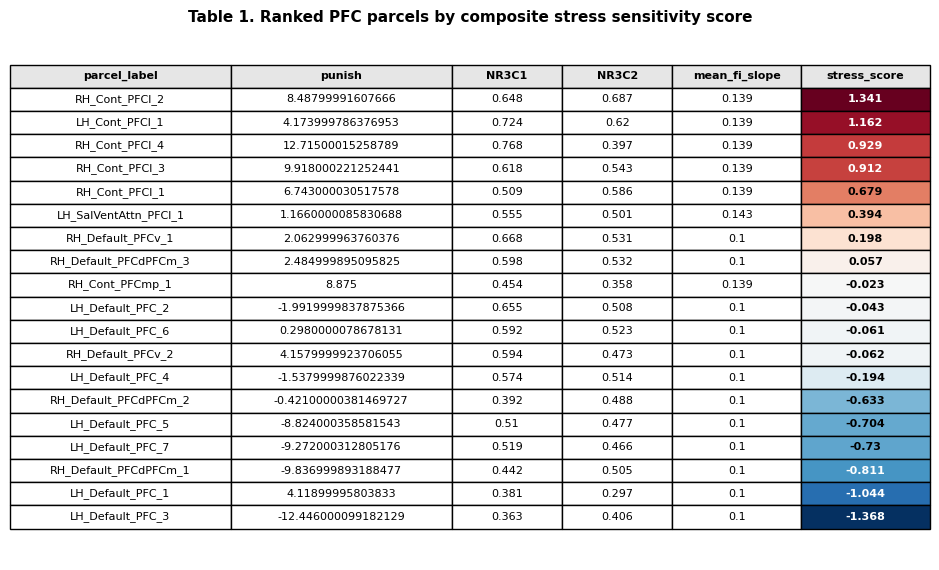

In [25]:
from scipy.stats import zscore
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# standardize each variable using z-scores so they are on comparable scales
combined_df['fMRI_z']  = zscore(combined_df['punish'].fillna(0))
combined_df['NR3C1_z'] = zscore(combined_df['NR3C1'].fillna(0))
combined_df['NR3C2_z'] = zscore(combined_df['NR3C2'].fillna(0))
combined_df['ephys_z'] = zscore(combined_df['mean_fi_slope'].fillna(0))

# compute a composite stress sensitivity score by averaging standardized variables
combined_df['stress_score'] = combined_df[
    ['fMRI_z', 'NR3C1_z', 'NR3C2_z', 'ephys_z']
].mean(axis=1)

# create a ranking table sorted by the composite stress sensitivity score
ranking = combined_df[
    ['parcel_label', 'punish', 'NR3C1', 'NR3C2', 'mean_fi_slope', 'stress_score']
].sort_values('stress_score', ascending=False).reset_index(drop=True)

ranking_display = ranking.copy()
ranking_display[['punish', 'NR3C1', 'NR3C2', 'mean_fi_slope', 'stress_score']] = (
    ranking_display[['punish', 'NR3C1', 'NR3C2', 'mean_fi_slope', 'stress_score']].round(3)
)

ranking_display['parcel_label'] = (
    ranking_display['parcel_label']
    .str.replace('7Networks_', '', regex=False)
)

cmap = plt.colormaps['RdBu_r']
norm = mcolors.Normalize(
    vmin=ranking_display['stress_score'].min(),
    vmax=ranking_display['stress_score'].max()
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.axis('off')

table = ax.table(
    cellText=ranking_display.values,
    colLabels=ranking_display.columns,
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[0.24, 0.24, 0.12, 0.12, 0.14, 0.14]
)

# identify which column corresponds to the composite stress score
stress_col = ranking_display.columns.get_loc('stress_score')
for i, val in enumerate(ranking_display['stress_score']):
    color = cmap(norm(val))
    table[(i + 1, stress_col)].set_facecolor(color)

    r, g, b, _ = color
    brightness = 0.299 * r + 0.587 * g + 0.114 * b
    table[(i + 1, stress_col)].set_text_props(
        color='white' if brightness < 0.55 else 'black',
        weight='bold'
    )

for j in range(len(ranking_display.columns)):
    table[(0, j)].set_facecolor('#E6E6E6')
    table[(0, j)].set_text_props(weight='bold', color='black')

for i in range(1, len(ranking_display) + 1):
    table[(i, 0)]._loc = 'left'
    table[(i, 0)].PAD = 0.02

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.18)

plt.title(
    "Table 1. Ranked PFC parcels by composite stress sensitivity score",
    fontsize=11,
    weight='bold',
    pad=8
)

plt.tight_layout()
plt.show()

This composite ranking highlights which PFC parcels show the strongest combined signal across punishment-related fMRI activation, stress receptor gene expression, and neuronal excitability. Parcels in red near the top represent regions where these functional, molecular, and cellular indicators of stress sensitivity align most strongly.

Most of the highest-ranked parcels belong to control-network PFC regions (Cont_PFC), roughly corresponding to dorsolateral prefrontal cortex (dlPFC), which is involved in cognitive control and decision-making under uncertainty. In contrast, parcels in blue and near the bottom are mostly Default-network PFC regions, likely corresponding to ventromedial PFC (vmPFC), which show weaker punishment activation and lower NR3C1 expression.

Overall, this ranking helps highlight specific PFC regions where activation, gene expression, and neuronal excitability converge, pointing to areas that may be particularly involved in stress-sensitive decision processes.

### Figure 3. Composite ranking of PFC stress sensitivity

This bar plot visualizes the composite stress sensitivity score for each PFC parcel.  
The score combines standardized measures of punishment-related fMRI activation, stress receptor gene expression (NR3C1 and NR3C2), and neuronal excitability.

Positive values indicate parcels where functional activation, receptor expression, and excitability converge toward a higher stress-sensitive profile, while negative values indicate parcels with comparatively weaker multimodal stress signatures.

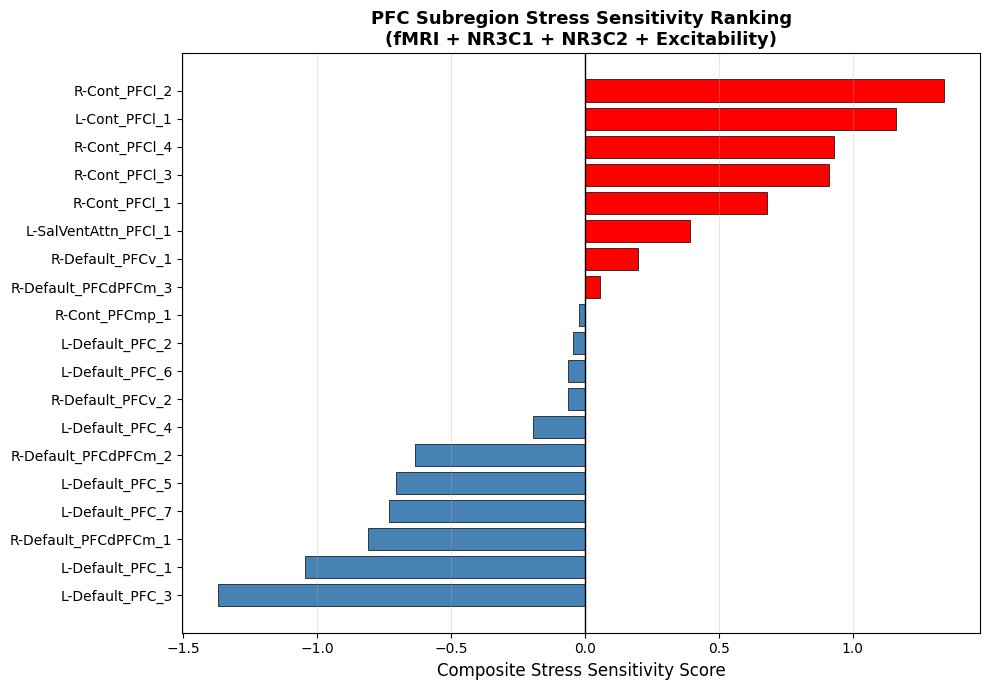

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))

# assign colors based on whether the stress score is positive or negative
colors = ['red' if s > 0 else 'steelblue' for s in ranking['stress_score']]
short_labels = [l.replace('7Networks_', '').replace('LH_', 'L-').replace('RH_', 'R-') 
                for l in ranking['parcel_label']]

# create the horizontal bar chart showing the stress sensitivity ranking
# reversing the order so the highest score appears at the top
bars = ax.barh(short_labels[::-1], ranking['stress_score'][::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Composite Stress Sensitivity Score', fontsize=12)
ax.set_title('PFC Subregion Stress Sensitivity Ranking\n(fMRI + NR3C1 + NR3C2 + Excitability)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\stress_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

This visualization highlights which PFC regions show the strongest combined evidence of stress sensitivity across the three modalities analyzed in this project.

The highest scores occur primarily in control-network PFC parcels (Cont_PFC), corresponding to dorsolateral prefrontal cortex regions. These areas show stronger punishment activation together with elevated NR3C1 expression and higher neuronal excitability, suggesting that executive-control regions of the PFC may be particularly responsive to stress-related signaling during negative outcomes.

In contrast, the lowest scores cluster within Default-network PFC parcels, which likely correspond to ventromedial or medial PFC regions. These areas show weaker punishment activation and lower composite scores, consistent with the known tendency of default-mode regions to decrease activity during demanding cognitive tasks.

Overall, this plot summarizes the central finding of the project: stress-related neural signatures are not uniformly distributed across the PFC, but instead appear strongest in lateral control-network regions involved in decision-making and cognitive control.

### Figure 4. Spatial distribution of PFC stress sensitivity

This figure maps the composite stress sensitivity score onto the cortical surface using the Schaefer atlas.  
Each parcel’s value reflects the combined contribution of punishment-related fMRI activation, stress receptor gene expression (NR3C1 and NR3C2), and neuronal excitability.

Red regions indicate parcels with higher composite stress sensitivity, while blue regions indicate parcels with weaker multimodal stress-related signatures. Visualizing the ranking spatially helps identify whether stress sensitivity is localized to specific functional subdivisions of the prefrontal cortex.

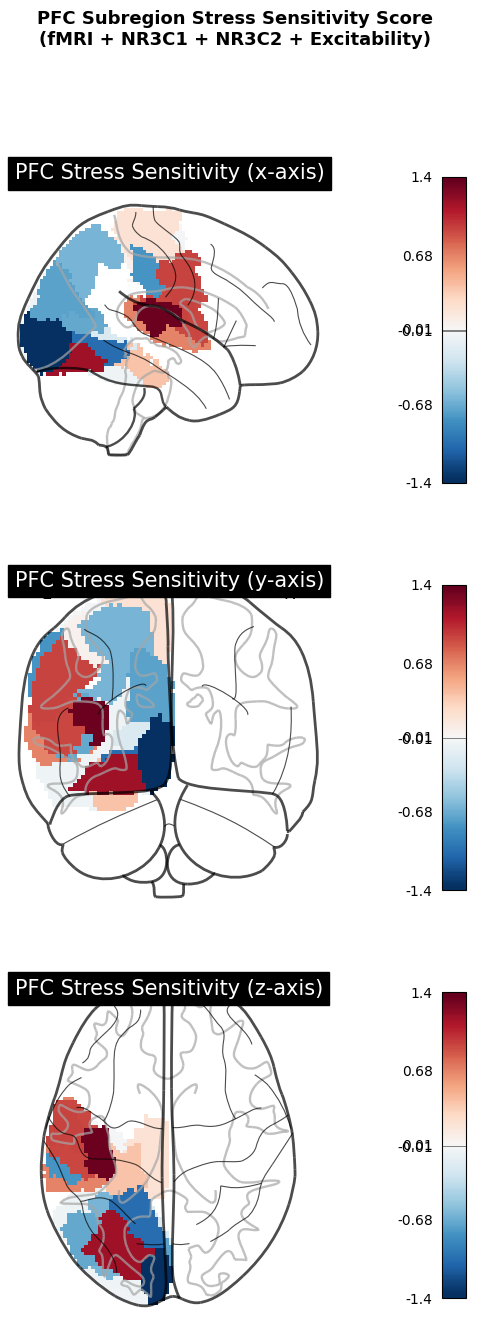

In [25]:
from nilearn import plotting, image

# build a nifti image with stress scores mapped onto parcels
atlas_data = image.load_img(atlas_img).get_fdata().copy()

# create an empty 3d array to store the stress sensitivity values
stress_map = np.zeros_like(atlas_data)

# loop through each row (parcel) in the combined dataframe
for _, row in combined_df.iterrows():
    parcel_idx = list(combined_df['parcel_label']).index(row['parcel_label']) # find the index of the current parcel label in the dataframe
    parcel_id  = parcel_idx + 1 # convert index to atlas parcel id (atlas ids start at 1)
    stress_map[atlas_data == parcel_id] = row['stress_score'] # assign the parcel's stress score to all voxels belonging to that parcel

# convert the stress score array back into a nifti image
stress_nii = image.new_img_like(atlas_img, stress_map)

# create a figure with three panels to display brain views along different axes
fig, axes = plt.subplots(3, 1, figsize=(6, 15))

# plot the brain map along sagittal (x), coronal (y), and axial (z) views
for ax, display_mode in zip(axes, ['x', 'y', 'z']):
    plotting.plot_glass_brain(
        stress_nii, # the nifti image containing stress sensitivity values
        colorbar=True,
        cmap='RdBu_r', # red = higher stress sensitivity, blue = lower
        display_mode=display_mode,
        threshold=0.01,
        title=f'PFC Stress Sensitivity ({display_mode}-axis)',
        axes=ax, 
        plot_abs=False
    )
plt.suptitle('PFC Subregion Stress Sensitivity Score\n(fMRI + NR3C1 + NR3C2 + Excitability)',
             fontsize=13, fontweight='bold')
# plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\brain_stress_map.png', dpi=150, bbox_inches='tight')
plt.show()

The spatial map further clarifies the anatomical distribution of stress-sensitive PFC regions identified in the composite ranking. Regions with the highest composite scores (red) cluster primarily in lateral prefrontal cortex, particularly within control-network parcels corresponding to dorsolateral PFC (dlPFC). These areas are visible across multiple views and appear slightly more prominent in the right hemisphere, suggesting that executive-control regions involved in monitoring negative outcomes may also exhibit stronger stress-related molecular and electrophysiological signatures.

In contrast, parcels with the lowest composite scores (dark blue) are concentrated in medial and ventral prefrontal regions, largely corresponding to default-network parcels that likely include ventromedial PFC (vmPFC). These areas appear most clearly in the inferior portion of the coronal view. This pattern is consistent with known functional properties of the default mode network, which often shows reduced activation during externally demanding tasks such as risk or punishment processing.

The spatial organization  reinforces the earlier ranking results: lateral control-network PFC regions show stronger multimodal stress sensitivity, whereas medial and ventral PFC regions appear comparatively less responsive in this composite measure. This pattern aligns with the broader hypothesis of the project that stress-related molecular and cellular properties may be linked to PFC regions involved in cognitive control during decision-making under negative outcomes.

### Figure 5. Parcel-level comparison of NR3C1 and NR3C2 expression across the PFC

This grouped bar plot compares the expression of the two stress receptor genes, NR3C1 and NR3C2, across individual prefrontal cortex parcels. Parcels are ordered by the difference between NR3C1 and NR3C2 expression to highlight regions with the strongest receptor imbalance.

Unlike the previous scatterplots, this figure is not meant to test whether gene expression predicts activation. Instead, it shows how the two receptor systems are distributed across the PFC and whether some parcels are relatively more glucocorticoid-receptor dominated or mineralocorticoid-receptor dominated.

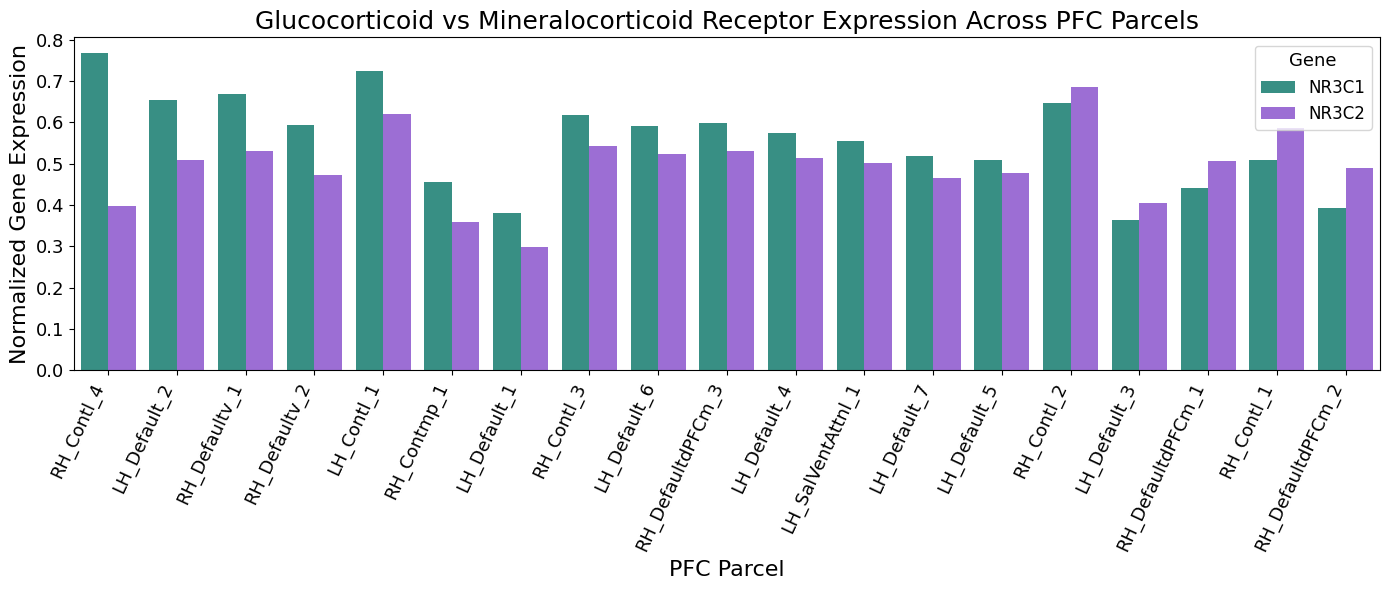

In [ ]:
# create a dataframe containing only the parcel labels and the two gene expression columns
gene_plot_df = combined_df[['parcel_label', 'NR3C1', 'NR3C2']].copy()

# compute the difference between nr3c1 and nr3c2
gene_plot_df['GR_minus_MR'] = gene_plot_df['NR3C1'] - gene_plot_df['NR3C2']

# sort parcels by the difference so regions with higher nr3c1 appear first
gene_plot_df = gene_plot_df.sort_values('GR_minus_MR', ascending=False)

gene_plot_df['short_label'] = gene_plot_df['parcel_label'] \
    .str.replace('7Networks_', '', regex=False) \
    .str.replace('_PFC', '', regex=False)

gene_long = gene_plot_df.melt(
    id_vars='short_label',
    value_vars=['NR3C1','NR3C2'],
    var_name='Gene',
    value_name='Expression'
)

plt.figure(figsize=(14,6))

# generate a grouped bar plot comparing nr3c1 and nr3c2 expression across parcels
order = gene_plot_df['short_label']

sns.barplot(
    data=gene_long,
    x='short_label',
    y='Expression',
    hue='Gene',
    order=order,
    palette={'NR3C1': '#2A9D8F', 'NR3C2': '#9B5DE5'}, # teal for GR, purple for MR
)

plt.xticks(rotation=65, ha='right', fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel("PFC Parcel", fontsize=16)
plt.ylabel("Normalized Gene Expression", fontsize=16)

plt.title("Glucocorticoid vs Mineralocorticoid Receptor Expression Across PFC Parcels", fontsize=18)

plt.legend(title="Gene", fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()

This figure shows that stress receptor expression is not uniform across the prefrontal cortex. Many parcels show higher NR3C1 than NR3C2, while others are more balanced or show the opposite pattern. This indicates that PFC subregions differ in their baseline receptor profile, rather than expressing the two stress receptors in the same proportions everywhere.

This pattern is important for the project because it helps explain why the relationship between punishment activation and gene expression was stronger for NR3C1 than for NR3C2. If some parcels are relatively enriched for glucocorticoid receptors, those regions may be more sensitive to cortisol-related stress signaling during task performance.

Overall, this plot provides molecular context for the functional results by showing that the PFC contains region-specific differences in stress receptor organization. These differences may contribute to why some parcels appear more stress-sensitive than others in the multimodal analyses. However, because the dataset provides only one normalized expression value per parcel for each gene, variability across samples could not be estimated and error bars were not included.

### Figure 6. Distribution of neuronal excitability across PFC regions

This violin plot shows the distribution of neuronal excitability measurements across broad prefrontal cortex regions in the Allen Cell Types dataset. Excitability is measured using the f–I curve slope, which reflects how strongly neuronal firing rate increases in response to injected current.

Unlike the parcel-level analyses above, which use regional averages, this plot visualizes the cell-level variability in electrophysiological properties across different PFC regions.

The x-axis shows four broad anatomical subdivisions of the prefrontal cortex used in the Allen Cell Types dataset:

• FroL — Frontal Lobe.
This region corresponds to a broad frontal lobe designation in the Allen Cell Types Database, encompassing neurons sampled from frontal cortical areas not specifically assigned to MFG, IFG, or SFG. The specific subregion of origin is unknown, and this category likely includes contributions from multiple prefrontal areas.

• MFG — Middle Frontal Gyrus.
This region corresponds broadly to dorsolateral prefrontal cortex (dlPFC), which is heavily involved in executive control, working memory, and cognitive regulation during decision-making.

• IFG — Inferior Frontal Gyrus.
This region lies along the lower lateral surface of the frontal lobe and is associated with behavioral inhibition, cognitive control, and response suppression.

• SFG — Superior Frontal Gyrus.
This region is located on the upper portion of the frontal lobe and includes parts of medial and dorsal PFC, which contribute to higher-order cognitive processes and monitoring of internally generated actions.

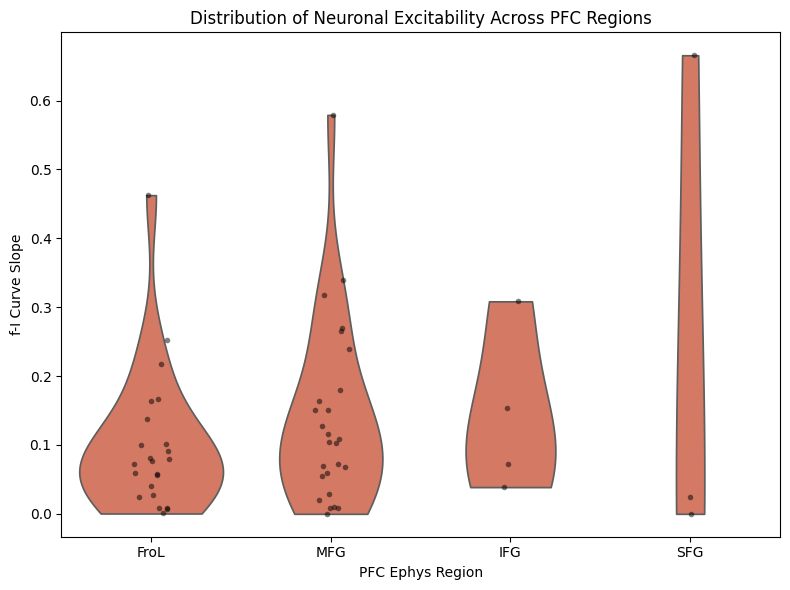

In [ ]:
# create a figure for the violin plot showing excitability distributions
plt.figure(figsize=(8,6))

# create violin plots to visualize the distribution of neuronal excitability
sns.violinplot(
    data=pfc_ephys,
    x='structure_area_abbrev',
    y='f_i_curve_slope', # excitability metric (slope of firing rate vs input current)
    color='#E76F51', # orange color for excitability
    inner=None,
    cut=0
)

# overlay individual neuron data points on top of the violin plot
sns.stripplot(
    data=pfc_ephys,
    x='structure_area_abbrev',
    y='f_i_curve_slope',
    color='black',
    size=4,
    alpha=0.5
)

plt.xlabel('PFC Ephys Region')
plt.ylabel('f-I Curve Slope')
plt.title('Distribution of Neuronal Excitability Across PFC Regions')

plt.tight_layout()
plt.show()


This figure shows the distribution of neuronal excitability across four anatomical subdivisions of the prefrontal cortex. Each violin represents the spread of f–I curve slope values, a measure of how strongly neuronal firing rate increases as input current increases. Larger values therefore indicate neurons that are more intrinsically responsive to stimulation.

Across regions, the middle frontal gyrus (MFG) shows the broadest distribution and includes some of the highest excitability values, suggesting substantial variability in neuronal responsiveness within this dorsolateral PFC region. Because the MFG corresponds broadly to dlPFC, a region heavily involved in executive control and decision-making, this variability may reflect the presence of neuronal populations with different response profiles supporting cognitive control functions.

The inferior frontal gyrus (IFG) and frontal lobe (FroL) show more moderate distributions with lower upper ranges, suggesting somewhat more constrained excitability profiles in these regions. The superior frontal gyrus (SFG) also shows a wide spread of values, indicating heterogeneity in neuronal responsiveness in dorsal/medial PFC areas.

Importantly, this figure illustrates that neuronal excitability varies across prefrontal regions and across individual neurons within those regions. Because electrophysiological recordings are collected at the level of single cells rather than large cortical parcels, visualizing this distribution provides context for the regional averages used in the multimodal analysis. These excitability differences support the inclusion of electrophysiology as a complementary modality when examining how cellular properties may relate to functional activation patterns and stress-related receptor expression across the PFC.

### Figure 7. Multiple regression model predicting punishment-related activation

To test whether molecular and electrophysiological features jointly predict task-related brain activation, we fit a **multiple linear regression model** predicting punishment-related fMRI activation across PFC parcels.

The predictors included:

- NR3C1 gene expression (glucocorticoid receptor)
- NR3C2 gene expression (mineralocorticoid receptor)
- neuronal excitability, measured as the mean f–I slope from electrophysiology data

This model tests whether variation in stress receptor expression and intrinsic neuronal excitability explains differences in punishment-related activation across prefrontal cortex regions.

In [28]:
import statsmodels.api as sm

# define the predictor variables for the regression model
X = combined_df[['NR3C1', 'NR3C2', 'mean_fi_slope']]

# define the response variable (dependent variable)
# here we are predicting punishment-related fmri activation
y = combined_df['punish']

# add a constant (intercept term) to the regression model
X = sm.add_constant(X)

# fit an ordinary least squares (ols) linear regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 punish   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     7.126
Date:                Fri, 13 Mar 2026   Prob (F-statistic):            0.00336
Time:                        19:20:32   Log-Likelihood:                -55.393
No. Observations:                  19   AIC:                             118.8
Df Residuals:                      15   BIC:                             122.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -28.2056      8.599     -3.280

c:\Users\user\myenv\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


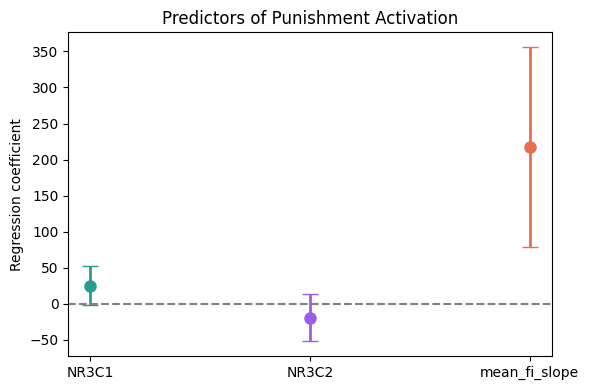

In [ ]:
# extract regression coefficients
coeffs = model.params.drop('const')

# extract confidence intervals
conf = model.conf_int().drop('const')

# create a dataframe containing regression coefficients and their confidence intervals
coef_df = pd.DataFrame({
    "predictor": coeffs.index, # names of predictors (nr3c1, nr3c2, excitability, etc.)
    "coef": coeffs.values, # estimated regression coefficients
    "lower": conf[0].values, # lower bound
    "upper": conf[1].values # upper bound
})

# define colors per predictor for consistency with other figures
predictor_colors = {
    'NR3C1': '#2A9D8F',        # teal - matches gene expression figure
    'NR3C2': '#9B5DE5',        # purple - matches gene expression figure
    'mean_fi_slope': '#E76F51' # orange - matches excitability figures
}
plt.figure(figsize=(6,4))

# plot each regression coefficient with error bars representing confidence intervals
for _, row in coef_df.iterrows():
    color = predictor_colors.get(row['predictor'], 'black')
    plt.errorbar(
        row['predictor'],
        row['coef'], 
        yerr=[[row['coef'] - row['lower']], [row['upper'] - row['coef']]],
        fmt='o',
        capsize=6,
        color=color,
        markersize=8,
        linewidth=2
    )

# draw a horizontal reference line at zero

plt.axhline(0, linestyle='--', color='gray')

plt.ylabel("Regression coefficient")
plt.title("Predictors of Punishment Activation")

plt.tight_layout()
plt.show()

The regression model explained a substantial proportion of the variance in punishment-related activation across PFC parcels (R² = 0.588), indicating that molecular and electrophysiological properties together capture meaningful differences in regional task activation.

Among the predictors, neuronal excitability (mean f–I slope) showed the strongest and most statistically significant effect (beta ≈ 217.7, p = 0.004). Parcels with neurons that increase firing rate more steeply with input current tend to show stronger punishment-related fMRI activation. This suggests that intrinsic cellular excitability may contribute to stronger population-level activity measured with BOLD signals.

NR3C1 (glucocorticoid receptor expression) showed a positive relationship with activation (beta ≈ 25.3) and approached statistical significance (p = 0.060). This trend is consistent with the known role of glucocorticoid receptors in stress-sensitive prefrontal circuits and suggests that regions with higher NR3C1 expression may be more responsive during punishment or risk-related decision making.

In contrast, NR3C2 (mineralocorticoid receptor expression) showed a weaker and non-significant effect (p = 0.224), suggesting that MR expression does not strongly track task-evoked activation across these PFC parcels. This is biologically plausible because NR3C2 is often associated with baseline cortisol regulation rather than dynamic stress responses.

Overall, these results indicate that neuronal excitability is the strongest predictor of functional activation, while NR3C1 expression shows a moderate positive relationship with stress-related activation, supporting the hypothesis that stress hormone receptor expression contributes to functional differences across prefrontal cortex regions during risk-based decision making.

# Overall Analysis Summary

This notebook explored whether functional activation in the prefrontal cortex during reward and punishment processing relates to stress-related gene expression and neuronal excitability. By integrating fMRI data from the Human Connectome Project with gene expression from the Allen Human Brain Atlas and electrophysiology data from the Allen Cell Types Database, we compared molecular, cellular, and functional signals across the same PFC regions.

We found that punishment-related activation showed a moderate positive relationship with NR3C1 expression (Spearman r = 0.463, p = 0.046), suggesting that regions more active during punishment outcomes may also express higher levels of glucocorticoid receptors. This is consistent with the role of NR3C1 in stress hormone signaling and suggests a possible link between stress-related molecular mechanisms and neural responses to negative outcomes.

A multiple regression model combining NR3C1 expression, NR3C2 expression, and neuronal excitability explained 58.8% of variance in punishment-related activation (R² = 0.588, p = 0.003), with neuronal excitability emerging as the strongest individual predictor.

Some limitations likely reduced statistical power. The analysis included only 19 PFC parcels, and electrophysiology measurements were mapped from broader anatomical regions rather than parcel-level recordings, meaning several parcels shared the same excitability values.

Overall, this notebook demonstrates how molecular, cellular, and functional datasets can be integrated to explore relationships across different levels of brain organization, and provides a foundation for more detailed future analyses with higher-resolution data.